In [1]:
from pathlib import Path
from typing import Union, Optional
import pandas as pd
import numpy as np
import logging
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Configure Logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)

In [2]:
# Use pathlib for robust path handling
BASE_DIR = Path.cwd().parent 
PROCESSED_DATA_DIR = BASE_DIR / "data_processed"
CONFIG_DIR = BASE_DIR / "config"
BRFSS_ZIP_FILE = PROCESSED_DATA_DIR / "BRFSS_2015_2024.zip"
BRFSS_CLEAN_ZIP_FILE = PROCESSED_DATA_DIR / "BRFSS_2015_2024_cleaned.zip"
RECODE_MAP_FILE = CONFIG_DIR / "recode_mappings.json"

# Ensure directories exist
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
def read_zipped_csv(
    zip_path: Union[str, Path],
    **read_csv_kwargs
) -> pd.DataFrame:
    """
    Read a single-CSV .zip file into a pandas DataFrame.

    Parameters
    ----------
    zip_path : str or Path
        Path to the .zip file (containing exactly one CSV, or a CSV
        with the same name as the zip).
    **read_csv_kwargs :
        Any extra keyword args passed through to pandas.read_csv
        (e.g. sep, dtype, parse_dates).

    Returns
    -------
    pd.DataFrame
    """
    zip_path = Path(zip_path)
    # For a single CSV in the zip, this is enough:
    return pd.read_csv(zip_path, compression="zip", **read_csv_kwargs)

In [4]:
def write_df_to_zipped_csv(
    df: pd.DataFrame,
    zip_path: Union[str, Path],
    csv_name: str | None = None,
    **to_csv_kwargs,
) -> None:
    """
    Write a DataFrame to a CSV stored inside a .zip file.

    Parameters
    ----------
    df : pd.DataFrame
        Data to write.
    zip_path : str or Path
        Path to the .zip file to create, e.g. 'data.zip'.
    csv_name : str, optional
        Name of the CSV file inside the zip, e.g. 'data.csv'.
        If None, uses the zip file stem with '.csv'.
    **to_csv_kwargs :
        Extra keyword args passed to DataFrame.to_csv
        (e.g. index=False, sep=',', encoding='utf-8').
    """
    zip_path = Path(zip_path)
    if csv_name is None:
        csv_name = zip_path.stem + ".csv"

    compression_opts = {
        "method": "zip",
        "archive_name": csv_name,
    }

    df.to_csv(
        zip_path,
        header=True,
        compression=compression_opts,
        **to_csv_kwargs,
    )

In [5]:
# Load the BRFSS data
df = read_zipped_csv(BRFSS_ZIP_FILE)
logging.info(f"Initial data loaded with {df.shape[0]} rows. and columns: {df.shape[1]}")

2026-01-20 23:50:52 - INFO - Initial data loaded with 4410255 rows. and columns: 21


In [6]:
def print_unique_values(data, columnName):
    unique_column_values = data[columnName].unique()
    if pd.api.types.is_numeric_dtype(unique_column_values):
        unique_column_values = np.sort(unique_column_values)
    column_datatype = data[columnName].dtype
    num_unique_column_values = len(unique_column_values)
    print(f'{num_unique_column_values} Unique values in column {columnName} of type {column_datatype}: {unique_column_values}')

# For each column, print unique values
for col in df.columns:
    print_unique_values(df, col)

10 Unique values in column YEAR of type int64: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
3 Unique values in column HEALTH_STATUS of type float64: [1. 2. 9.]
5 Unique values in column PHYSICAL_HEALTH_STATUS of type float64: [ 1.  2.  3.  9. nan]
4 Unique values in column MENTAL_HEALTH_STATUS of type int64: [1 2 3 9]
3 Unique values in column EXERCISE of type float64: [1. 2. 9.]
3 Unique values in column HEALTH_CARE_COVERAGE of type float64: [1. 2. 9.]
5 Unique values in column SMOKER of type float64: [1. 2. 3. 4. 9.]
4 Unique values in column DRINKER of type float64: [1. 2. 7. 9.]
3 Unique values in column SOCIAL_DRINKER of type float64: [1. 2. 9.]
3 Unique values in column HEAVY_ALCOHOL_CONSUMPTION of type float64: [1. 2. 9.]
3 Unique values in column HEART_ATTACK of type float64: [ 1.  2. nan]
5 Unique values in column STROKE of type float64: [ 1.  2.  7.  9. nan]
7 Unique values in column DIABETES of type float64: [ 1.  2.  3.  4.  7.  9. nan]
3 Unique values in column ARTH

In [7]:
# For each column, replace 'Not Sure' or 'Refused' codes with NaN

replace_unsure_refused = {
    'HEALTH_STATUS': {9: np.nan},
    'PHYSICAL_HEALTH_STATUS': {9: np.nan},
    'MENTAL_HEALTH_STATUS': {9: np.nan},
    'EXERCISE': {9: np.nan},
    'HEALTH_CARE_COVERAGE': {9: np.nan},
    'SMOKER': {9: np.nan},
    'DRINKER': {7: np.nan, 9: np.nan},
    'SOCIAL_DRINKER': {9: np.nan},
    'HEAVY_ALCOHOL_CONSUMPTION': {9: np.nan},
    #'HEART_ATTACK': {},
    'STROKE': {7: np.nan, 9: np.nan},
    'DIABETES': {7: np.nan, 9: np.nan},
    #'ARTHRITIS': {},
    'MARITAL_STATUS': {9: np.nan},
    'EMPLOYMENT': {9: np.nan},
    'SEX': {7: np.nan, 9: np.nan},
    'AGE_CATEGORIES': {14: np.nan},
    #'BMICAT': {},
    'EDUCATION_LEVEL': {9: np.nan},
    'INCOME': {9: np.nan}
}

df.replace(replace_unsure_refused, inplace=True)

In [8]:
# For each column, print unique values
for col in df.columns:
    print_unique_values(df, col)

10 Unique values in column YEAR of type int64: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
3 Unique values in column HEALTH_STATUS of type float64: [ 1.  2. nan]
4 Unique values in column PHYSICAL_HEALTH_STATUS of type float64: [ 1.  2.  3. nan]
4 Unique values in column MENTAL_HEALTH_STATUS of type float64: [ 1.  2.  3. nan]
3 Unique values in column EXERCISE of type float64: [ 1.  2. nan]
3 Unique values in column HEALTH_CARE_COVERAGE of type float64: [ 1.  2. nan]
5 Unique values in column SMOKER of type float64: [ 1.  2.  3.  4. nan]
3 Unique values in column DRINKER of type float64: [ 1.  2. nan]
3 Unique values in column SOCIAL_DRINKER of type float64: [ 1.  2. nan]
3 Unique values in column HEAVY_ALCOHOL_CONSUMPTION of type float64: [ 1.  2. nan]
3 Unique values in column HEART_ATTACK of type float64: [ 1.  2. nan]
3 Unique values in column STROKE of type float64: [ 1.  2. nan]
5 Unique values in column DIABETES of type float64: [ 1.  2.  3.  4. nan]
3 Unique values in c

In [9]:
def recode_column(df, col_name, old_values, new_values):
    if len(old_values) != len(new_values):
        raise ValueError("old_values and new_values must have same length")
    mapping = dict(zip(old_values, new_values))
    df[col_name] = df[col_name].replace(mapping)
    return df

def apply_recode_map(df, map_file=RECODE_MAP_FILE):
    with open(map_file, 'r') as f:
        recode_map = json.load(f)
    
    for col_name, mapping in recode_map.items():
        if mapping.get('multi_step'):
            # Handle grouped (e.g. SMOKER)
            no_codes = mapping['no_codes']
            yes_codes = mapping['yes_codes']
            df.loc[df[col_name].isin(no_codes), col_name] = '0'
            df.loc[df[col_name].isin(yes_codes), col_name] = '1'
        else:
            # Direct 1:1
            old_vals = mapping['old_values']
            new_vals = mapping['new_values']
            df = recode_column(df, col_name, old_vals, new_vals)
    
    # Drop rows with remaining missing values (9, 7, 14, etc.) or set to NaN
    df = df.replace(['9', '7', '14', 'Not sure', 'Refused'], pd.NA)
    
    return df

# Apply to your DataFrame
df = apply_recode_map(df)

In [10]:
# For each column, print unique values
for col in df.columns:
    print_unique_values(df, col)

10 Unique values in column YEAR of type int64: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
3 Unique values in column HEALTH_STATUS of type float64: [ 1.  2. nan]
4 Unique values in column PHYSICAL_HEALTH_STATUS of type float64: [ 1.  2.  3. nan]
4 Unique values in column MENTAL_HEALTH_STATUS of type float64: [ 1.  2.  3. nan]
3 Unique values in column EXERCISE of type float64: [ 1.  2. nan]
3 Unique values in column HEALTH_CARE_COVERAGE of type float64: [ 1.  2. nan]
5 Unique values in column SMOKER of type float64: [ 1.  2.  3.  4. nan]
3 Unique values in column DRINKER of type float64: [ 1.  2. nan]
3 Unique values in column SOCIAL_DRINKER of type float64: [ 1.  2. nan]
3 Unique values in column HEAVY_ALCOHOL_CONSUMPTION of type float64: [ 1.  2. nan]
3 Unique values in column HEART_ATTACK of type float64: [ 1.  2. nan]
3 Unique values in column STROKE of type float64: [ 1.  2. nan]
5 Unique values in column DIABETES of type float64: [ 1.  2.  3.  4. nan]
3 Unique values in c

In [11]:
# Drop duplicate rows
logging.info("Dropping duplicate rows from the dataset.")
initial_row_count = df.shape[0]
df.drop_duplicates(inplace=True)
logging.info(f"Data after dropping duplicates has {df.shape[0]} rows (dropped {initial_row_count - df.shape[0]} duplicates).")

2026-01-20 23:51:03 - INFO - Dropping duplicate rows from the dataset.
2026-01-20 23:51:05 - INFO - Data after dropping duplicates has 2880717 rows (dropped 1529538 duplicates).


In [12]:
# Cleanse and process the data as needed
logging.info("Dropping rows with missing data.")
initial_row_count = df.shape[0]
df.dropna(inplace=True)
logging.info(f"Data after dropping missing rows has {df.shape[0]} rows (dropped {initial_row_count - df.shape[0]} missing data rows).")

2026-01-20 23:51:05 - INFO - Dropping rows with missing data.
2026-01-20 23:51:06 - INFO - Data after dropping missing rows has 1099757 rows (dropped 1780960 missing data rows).


In [13]:
# For each column, print unique values
for col in df.columns:
    print_unique_values(df, col)

10 Unique values in column YEAR of type int64: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
2 Unique values in column HEALTH_STATUS of type float64: [1. 2.]
3 Unique values in column PHYSICAL_HEALTH_STATUS of type float64: [1. 2. 3.]
3 Unique values in column MENTAL_HEALTH_STATUS of type float64: [1. 2. 3.]
2 Unique values in column EXERCISE of type float64: [1. 2.]
2 Unique values in column HEALTH_CARE_COVERAGE of type float64: [1. 2.]
4 Unique values in column SMOKER of type float64: [1. 2. 3. 4.]
2 Unique values in column DRINKER of type float64: [1. 2.]
2 Unique values in column SOCIAL_DRINKER of type float64: [1. 2.]
2 Unique values in column HEAVY_ALCOHOL_CONSUMPTION of type float64: [1. 2.]
2 Unique values in column HEART_ATTACK of type float64: [1. 2.]
2 Unique values in column STROKE of type float64: [1. 2.]
4 Unique values in column DIABETES of type float64: [1. 2. 3. 4.]
2 Unique values in column ARTHRITIS of type float64: [1. 2.]
6 Unique values in column MARITAL_STA

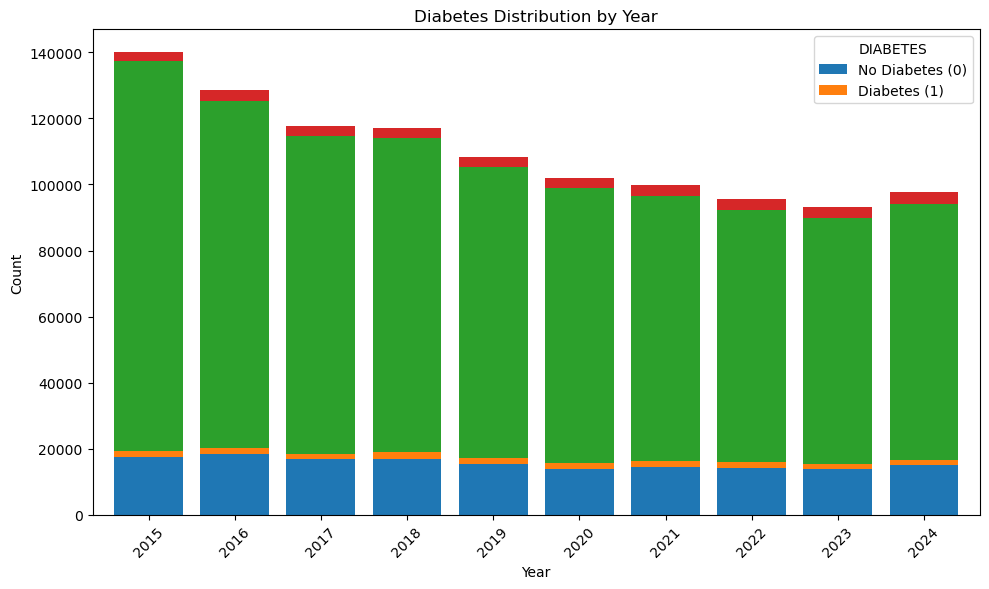

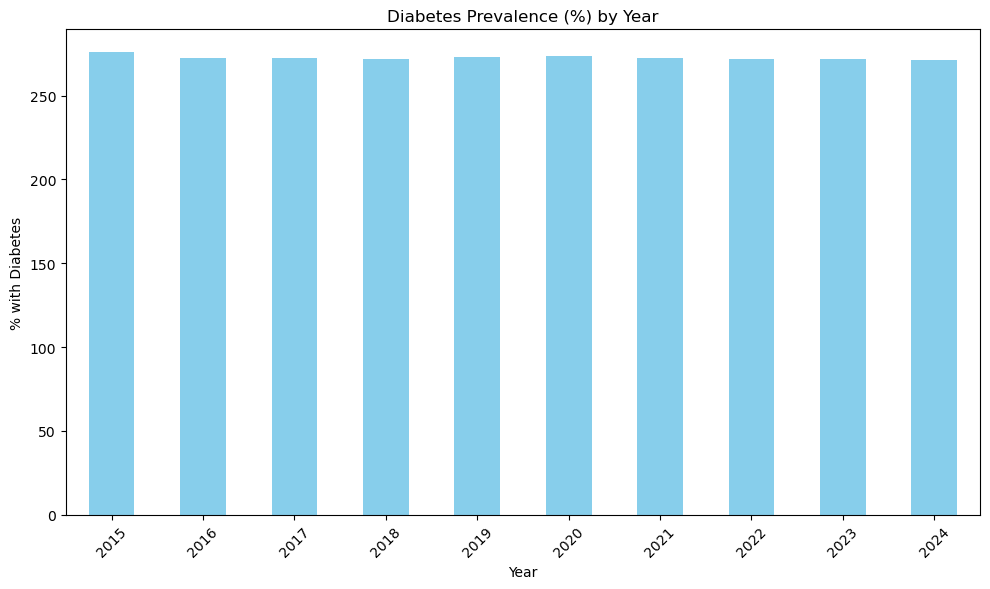

In [14]:
# Assuming df is your recoded DataFrame with 'DIABETES' (0=No, 1=Yes) and 'YEAR' columns
# If YEAR column name differs (e.g. 'year', 'survey_year'), adjust accordingly

# Group by year and diabetes status, count occurrences
diabetes_by_year = df.groupby(['YEAR', 'DIABETES']).size().unstack(fill_value=0)

# Plot stacked bar chart (total N per year, proportion diabetes)
fig, ax = plt.subplots(figsize=(10, 6))
diabetes_by_year.plot(kind='bar', stacked=True, ax=ax, width=0.8)

ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.set_title('Diabetes Distribution by Year')
ax.legend(['No Diabetes (0)', 'Diabetes (1)'], title='DIABETES')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Alternative: proportion of diabetes per year
diabetes_pct = df.groupby('YEAR')['DIABETES'].mean() * 100
diabetes_pct.plot(kind='bar', color='skyblue', figsize=(10, 6))
plt.title('Diabetes Prevalence (%) by Year')
plt.ylabel('% with Diabetes')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


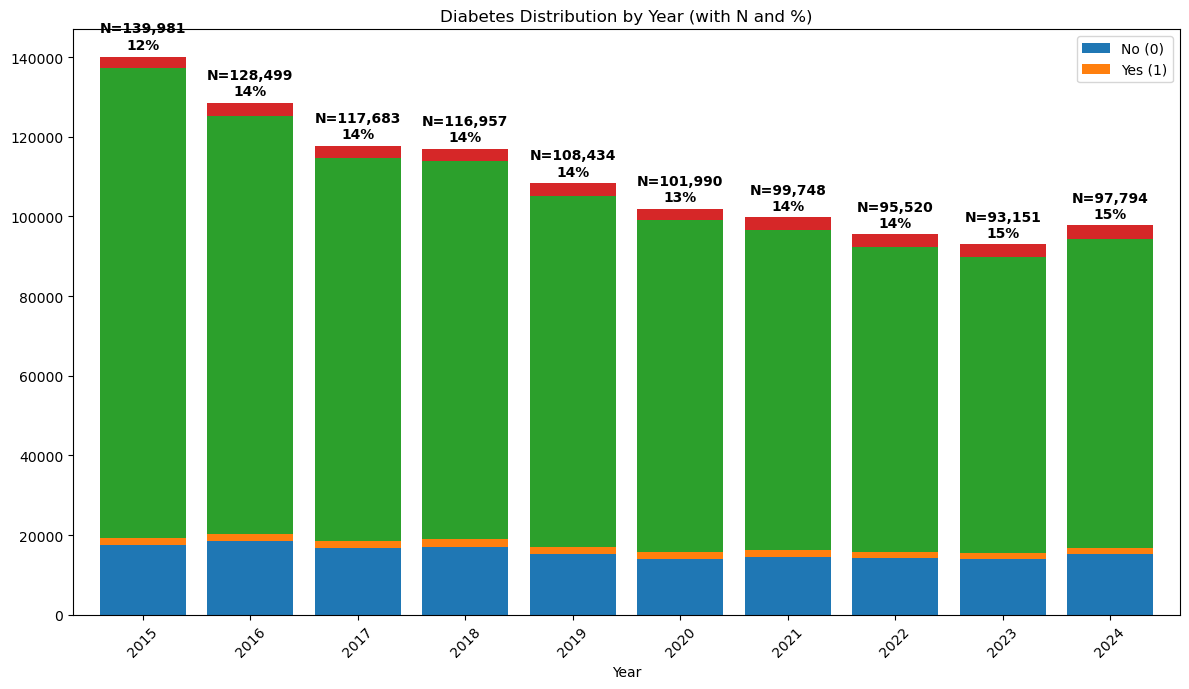

In [15]:
diabetes_by_year = df.groupby(['YEAR', 'DIABETES']).size().unstack(fill_value=0)
totals = diabetes_by_year.sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 7))
bars = diabetes_by_year.plot(kind='bar', stacked=True, ax=ax, width=0.8)

# Add total N and % labels on top of each bar
for i, (year, total) in enumerate(totals.items()):
    diabetes_n = diabetes_by_year.loc[year, 1] if 1 in diabetes_by_year.columns else 0
    pct = (diabetes_n / total * 100).round(1)
    ax.text(i, total + total*0.01, f'N={total:,}\n{int(pct)}%', 
            ha='center', va='bottom', fontweight='bold')

ax.set_title('Diabetes Distribution by Year (with N and %)')
ax.legend(['No (0)', 'Yes (1)'])
ax.set_xlabel('Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
logging.info("Data information:\n")
df.info()

2026-01-20 23:51:07 - INFO - Data information:



<class 'pandas.core.frame.DataFrame'>
Index: 1099757 entries, 0 to 4410254
Data columns (total 21 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   YEAR                       1099757 non-null  int64  
 1   HEALTH_STATUS              1099757 non-null  float64
 2   PHYSICAL_HEALTH_STATUS     1099757 non-null  float64
 3   MENTAL_HEALTH_STATUS       1099757 non-null  float64
 4   EXERCISE                   1099757 non-null  float64
 5   HEALTH_CARE_COVERAGE       1099757 non-null  float64
 6   SMOKER                     1099757 non-null  float64
 7   DRINKER                    1099757 non-null  float64
 8   SOCIAL_DRINKER             1099757 non-null  float64
 9   HEAVY_ALCOHOL_CONSUMPTION  1099757 non-null  float64
 10  HEART_ATTACK               1099757 non-null  float64
 11  STROKE                     1099757 non-null  float64
 12  DIABETES                   1099757 non-null  float64
 13  ARTHRITIS        

In [17]:
logging.info("Data description:\n")
df.describe()

2026-01-20 23:51:07 - INFO - Data description:



,YEAR,HEALTH_STATUS,PHYSICAL_HEALTH_STATUS,MENTAL_HEALTH_STATUS,EXERCISE,HEALTH_CARE_COVERAGE,SMOKER,DRINKER,SOCIAL_DRINKER,HEAVY_ALCOHOL_CONSUMPTION,...,STROKE,DIABETES,ARTHRITIS,MARITAL_STATUS,EMPLOYMENT,SEX,AGE_CATEGORIES,BMICAT,EDUCATION_LEVEL,INCOME
count,1.099757e+06,1.099757e+06,1.099757e+06,1.099757e+06,1.099757e+06,1.099757e+06,1.099757e+06,1.099757e+06,1.099757e+06,1.099757e+06,...,1.099757e+06,1.099757e+06,1.099757e+06,1.099757e+06,1.099757e+06,1.099757e+06,1.099757e+06,1.099757e+06,1.099757e+06,1.099757e+06
mean,2.019138e+03,1.251249e+00,1.952161e+00,1.951024e+00,1.309970e+00,1.148637e+00,3.033771e+00,1.471138e+00,1.210229e+00,1.096099e+00,...,1.959234e+00,2.728263e+00,1.681731e+00,2.722461e+00,3.098628e+00,1.528444e+00,5.847046e+00,3.088890e+00,2.788471e+00,3.521358e+00
std,2.901549e+00,4.337317e-01,2.998183e-01,3.005269e-01,4.624812e-01,3.557308e-01,1.135307e+00,4.991665e-01,4.074715e-01,2.947264e-01,...,1.977484e-01,7.346956e-01,4.658049e-01,1.849767e+00,2.655214e+00,4.991905e-01,2.556020e+00,8.557145e-01,9.530896e-01,1.465354e+00
min,2.015000e+03,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,2.017000e+03,1.000000e+00,2.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,2.000000e+00,3.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00
50%,2.019000e+03,1.000000e+00,2.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,2.000000e+00,3.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,6.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00
75%,2.022000e+03,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,1.000000e+00,4.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,...,2.000000e+00,3.000000e+00,2.000000e+00,5.000000e+00,5.000000e+00,2.000000e+00,8.000000e+00,4.000000e+00,4.000000e+00,5.000000e+00
max,2.024000e+03,2.000000e+00,3.000000e+00,3.000000e+00,2.000000e+00,2.000000e+00,4.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,...,2.000000e+00,4.000000e+00,2.000000e+00,6.000000e+00,8.000000e+00,2.000000e+00,9.000000e+00,4.000000e+00,4.000000e+00,5.000000e+00


In [18]:
logging.info("First few rows of the dataset:")
df.head()

2026-01-20 23:51:08 - INFO - First few rows of the dataset:


,YEAR,HEALTH_STATUS,PHYSICAL_HEALTH_STATUS,MENTAL_HEALTH_STATUS,EXERCISE,HEALTH_CARE_COVERAGE,SMOKER,DRINKER,SOCIAL_DRINKER,HEAVY_ALCOHOL_CONSUMPTION,...,STROKE,DIABETES,ARTHRITIS,MARITAL_STATUS,EMPLOYMENT,SEX,AGE_CATEGORIES,BMICAT,EDUCATION_LEVEL,INCOME
0,2015,2.0,3.0,3.0,2.0,1.0,3.0,2.0,1.0,1.0,...,2.0,3.0,1.0,1.0,8.0,2.0,9.0,4.0,2.0,2.0
1,2015,1.0,1.0,1.0,1.0,2.0,1.0,2.0,1.0,1.0,...,2.0,3.0,2.0,2.0,3.0,2.0,7.0,3.0,4.0,1.0
3,2015,2.0,3.0,3.0,2.0,1.0,4.0,2.0,1.0,1.0,...,2.0,3.0,1.0,1.0,8.0,2.0,9.0,3.0,2.0,5.0
10,2015,1.0,3.0,1.0,2.0,1.0,3.0,2.0,1.0,1.0,...,2.0,3.0,2.0,1.0,7.0,2.0,9.0,4.0,4.0,5.0
16,2015,2.0,3.0,3.0,2.0,1.0,1.0,2.0,1.0,1.0,...,2.0,1.0,1.0,6.0,8.0,2.0,9.0,4.0,3.0,1.0


In [19]:
logging.info(f"The BRFSS 2015-2024 dataset has been successfully prepared and is ready for analysis and had {df.shape[0]} rows and {df.shape[1]} columns.")

2026-01-20 23:51:08 - INFO - The BRFSS 2015-2024 dataset has been successfully prepared and is ready for analysis and had 1099757 rows and 21 columns.


In [20]:
logging.info("Write the cleaned dataset to csv")
write_df_to_zipped_csv(df, BRFSS_CLEAN_ZIP_FILE, index=False)

2026-01-20 23:51:08 - INFO - Write the cleaned dataset to csv
